# Display GPX data on map

Experiment in mapping software in particular geopandas. Where I use geopandas load and  display GPS data on top. The GPS is one of my recent runs downloaded from Garmin connect.

Reference code from:
* https://medium.com/codetodeploy/how-hard-can-it-be-to-display-gpx-on-map-using-python-not-really-93a4f1617d0d
* https://github.com/florianneukirchen/jupyter-notebooks/blob/main/gpx-track.ipynb


In [1]:
import geopandas as gpd
import pandas as pd
import contextily as cx
import matplotlib.pyplot as plt

In [2]:
filename="sligo_run_dec28.gpx"

## GPX layers

The gpx file contains a list of layers that we want to explore and plot of the map. When we read the file into a DataFrame we must select the layer we want.

routes is one feature contain a geometry of the route I took.

track_points and waypokints (note sure the difference between these two) and these contain the points saved from GPS.

In [3]:
gpd.list_layers(filename)

,name,geometry_type
0,waypoints,Point
1,routes,LineString
2,tracks,MultiLineString
3,route_points,Point
4,track_points,Point


In [4]:
routes = gpd.read_file(filename, layer="routes")
routes.head()

,name,cmt,desc,src,link1_href,link1_text,link1_type,link2_href,link2_text,link2_type,number,type,geometry


### tracks layer


In [5]:
tracks = gpd.read_file(filename, layer="tracks")
tracks.head()

,name,cmt,desc,src,link1_href,link1_text,link1_type,link2_href,link2_text,link2_type,number,type,geometry
0,County Sligo Running,None,None,None,None,None,None,None,None,None,NaN,running,"MULTILINESTRING ((-8.48754 54.31365, -8.48758 ..."


In [6]:
tracks.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

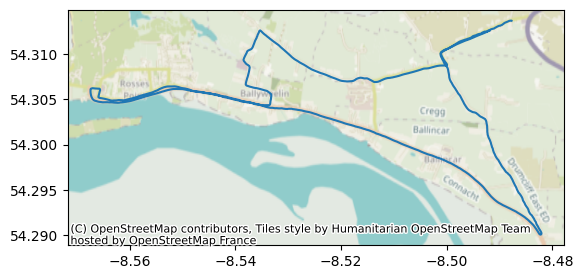

In [7]:
fig, ax = plt.subplots()
tracks.plot(ax=ax)
cx.add_basemap(ax, crs=tracks.crs)

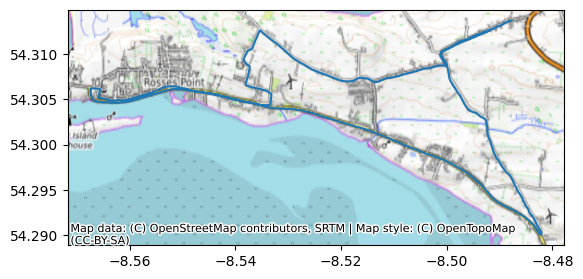

In [8]:
fig, ax = plt.subplots()
tracks.plot(ax=ax)
cx.add_basemap(ax, crs=tracks.crs, source=cx.providers.OpenTopoMap)

### waypoints

In [9]:
waypoints = gpd.read_file(filename, layer="track_points")
waypoints.head()

,track_fid,track_seg_id,track_seg_point_id,ele,time,magvar,geoidheight,name,cmt,desc,...,sym,type,fix,sat,hdop,vdop,pdop,ageofdgpsdata,dgpsid,geometry
0,0,0,0,32.799999,2025-12-28 14:56:59+00:00,NaN,NaN,None,None,None,...,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-8.48754 54.31365)
1,0,0,1,32.599998,2025-12-28 14:57:00+00:00,NaN,NaN,None,None,None,...,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-8.48758 54.31366)
2,0,0,2,32.200001,2025-12-28 14:57:02+00:00,NaN,NaN,None,None,None,...,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-8.48769 54.31369)
3,0,0,3,32.400002,2025-12-28 14:57:03+00:00,NaN,NaN,None,None,None,...,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-8.48777 54.3137)
4,0,0,4,33.400002,2025-12-28 14:57:05+00:00,NaN,NaN,None,None,None,...,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-8.4879 54.3137)


In [10]:
waypoints.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1147 entries, 0 to 1146
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   track_fid           1147 non-null   int32              
 1   track_seg_id        1147 non-null   int32              
 2   track_seg_point_id  1147 non-null   int32              
 3   ele                 1147 non-null   float64            
 4   time                1147 non-null   datetime64[ms, UTC]
 5   magvar              0 non-null      float64            
 6   geoidheight         0 non-null      float64            
 7   name                0 non-null      object             
 8   cmt                 0 non-null      object             
 9   desc                0 non-null      object             
 10  src                 0 non-null      object             
 11  link1_href          0 non-null      object             
 12  link1_text          0 non-

In [11]:
points = waypoints.geometry
waypoints.crs, points[0].x, points[0].y

(<Geographic 2D CRS: EPSG:4326>
 Name: WGS 84
 Axis Info [ellipsoidal]:
 - Lat[north]: Geodetic latitude (degree)
 - Lon[east]: Geodetic longitude (degree)
 Area of Use:
 - name: World.
 - bounds: (-180.0, -90.0, 180.0, 90.0)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich,
 -8.487535519525409,
 54.31364634074271)

In [12]:
points[0].coords.xy

(array('d', [-8.487535519525409]), array('d', [54.31364634074271]))

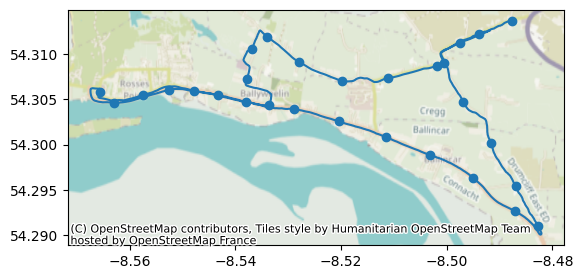

In [13]:
ax = tracks.plot()
geom = waypoints["geometry"]
gdf = gpd.GeoDataFrame({"geometry": geom[0:len(geom) - 1:40]})
gdf.plot(ax=ax)
cx.add_basemap(ax, crs=tracks.crs)

## Elevation of my route

The waypoints also contains a ele column containing the elevation of my route

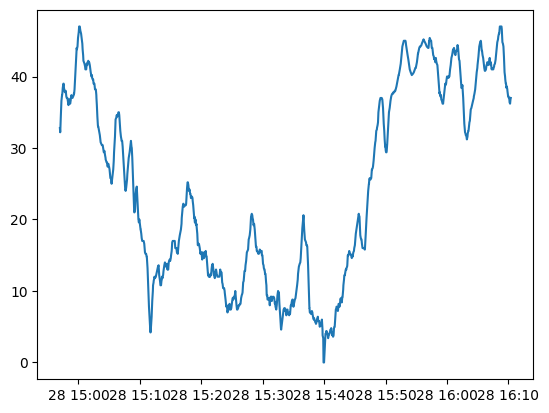

In [14]:
plt.plot(waypoints["time"], waypoints["ele"])

In [15]:
ele = pd.DataFrame(waypoints["ele"])
ele.head()

,ele
0,32.799999
1,32.599998
2,32.200001
3,32.400002
4,33.400002


<Axes: >

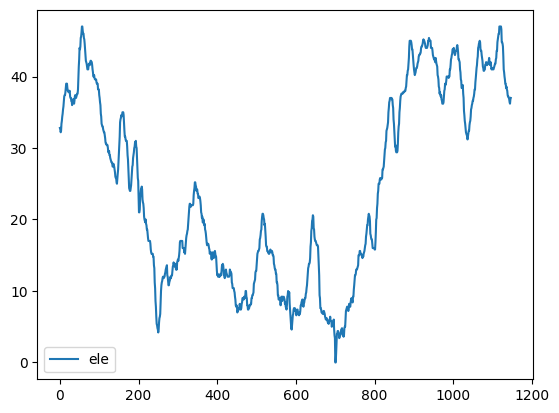

In [16]:
ele.plot()